In [1]:
import pickle

# Unpickle the file
with open(r"C:\Users\jishn\Downloads\Internship\Face Recognition\Face Recognition\clean_data\images.p", "rb") as f:
  images = pickle.load(f)

with open(r"C:\Users\jishn\Downloads\Internship\Face Recognition\Face Recognition\clean_data\labels.p", "rb") as f:
  labels = pickle.load(f)

In [2]:
print(images.shape)
print(labels.shape)

(400, 100, 100)
(400,)


In [3]:
set(labels)

{'Jishnu', 'Oreo', 'Pratyush', 'animesh'}

In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels = le.fit_transform(labels)

In [5]:
set(labels)

{0, 1, 2, 3}

In [6]:
import numpy as np
n_persons = len(set(labels))
print("Number of persons: ", n_persons)
label_mapping = le.inverse_transform(np.arange(n_persons))
for i in range(len(label_mapping)):
  print(i, "-->", label_mapping[i])

Number of persons:  4
0 --> Jishnu
1 --> Oreo
2 --> Pratyush
3 --> animesh


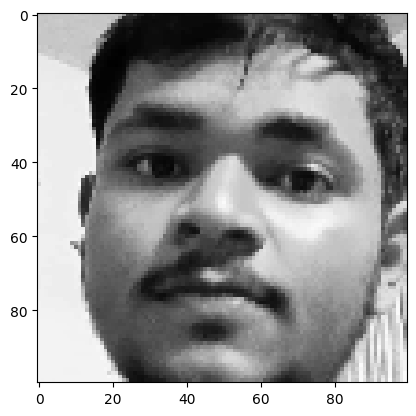

In [7]:
import matplotlib.pyplot as plt

plt.imshow(images[110], cmap=plt.get_cmap("gray"))
plt.show()

In [8]:
import cv2
def preprocessing(img):
  img = cv2.equalizeHist(img)
  img = img.reshape(100, 100, 1)
  img = img/255
  return img

In [9]:
images = np.array(list(map(preprocessing, images)))
print("Shape of Input: ", images.shape)

Shape of Input:  (400, 100, 100, 1)


In [10]:
from tensorflow.keras.utils import to_categorical

In [11]:
labels = to_categorical(labels)

In [12]:
categories = labels.shape[1]
print(categories)

4


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
# import convolution layer
from tensorflow.keras.layers import Conv2D
# import pooling layer
from tensorflow.keras.layers import MaxPooling2D
# import faltten layer
from tensorflow.keras.layers import Flatten
from tensorflow.keras.optimizers import Adam

In [14]:
model = Sequential()
model.add(Conv2D(64, (5,5), input_shape=(100, 100, 1), activation="relu"))
model.add(Conv2D(64, (5,5), activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(32, (3,3), activation="relu"))
model.add(Conv2D(32, (3,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(512, activation="relu"))

model.add(Dense(4, activation="softmax"))
model.compile(Adam(learning_rate=0.0001), loss="categorical_crossentropy", metrics=['accuracy'])

C:\Users\jishn\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 96, 96, 64)          │           1,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 92, 92, 64)          │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 46, 46, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 44, 44, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 42, 42, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 21, 21, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 14112)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       7,225,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           2,052 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,359,748 (28.08 MB)

 Trainable params: 7,359,748 (28.08 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
h=model.fit(images,labels,validation_split=0.2,batch_size=50,epochs=10,verbose=1)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 5s/step - accuracy: 0.7344 - loss: 1.1932 - val_accuracy: 0.0000e+00 - val_loss: 3.1242
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 36s 5s/step - accuracy: 0.9000 - loss: 0.7126 - val_accuracy: 0.0000e+00 - val_loss: 2.9228
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 39s 5s/step - accuracy: 0.9187 - loss: 0.3002 - val_accuracy: 0.9375 - val_loss: 0.3911
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 47s 7s/step - accuracy: 0.9563 - loss: 0.1945 - val_accuracy: 0.9125 - val_loss: 0.5176
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 39s 5s/step - accuracy: 0.9750 - loss: 0.1303 - val_accuracy: 0.9125 - val_loss: 0.6355
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - accuracy: 0.9719 - loss: 0.1245 - val_accuracy: 0.9250 - val_loss: 0.5679
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 33s 5s/step - accuracy: 0.9781 - loss: 0.0791 - val_accuracy: 0.8375 - val_loss: 0.7852
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 33s 5s/step - accuracy: 0.9875 - loss: 0.0703 - val_accuracy: 0.8500 - val_loss: 0.8946


In [17]:
d=list(upload.keys())[0]

NameError: name 'upload' is not defined

In [ ]:
import cv2
a=np.fromstring(upload[d],np.uint8)
img=cv2.imdecode(a,cv2.IMREAD_COLOR)
img=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
print(a)
plt.imshow(img,cmap=plt.get_cmap("gray"))

In [ ]:

img=np.asarray(img)
img=cv2.resize(img,(100,100))
img=preprocessing(img)


In [ ]:
img=img.reshape(1,100,100,1)
print(model.predict(img))

In [ ]:
prediction=model.predict(img)

In [ ]:
p=np.argmax(prediction,axis=1)
p

In [24]:
model.save('finalmodel.h5')

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("finalmodel.h5", compile=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')